# Laboratorio Práctico: Ética en IA, Sesgos y Explicabilidad

En este ejercicio entrenaremos un modelo Random Forest para evaluar solicitudes de crédito. Luego, utilizaremos las herramientas SHAP y LIME para interpretar y explicar sus predicciones, analizando si existen sesgos discriminatorios en sus decisiones (por ejemplo, por género o nacionalidad).

**Contexto de los datos.** Utilizamos 1,500 registros generados sintéticamente, inspirados en el clásico dataset German Credit. Se ha introducido intencionalmente una regla de penalización para mujeres y extranjeros con el fin de verificar si los métodos de explicabilidad (SHAP y LIME) son capaces de detectar este comportamiento injusto.

## Etapa 1: Construcción del modelo predictivo

Primero, instalamos las dependencias necesarias, creamos nuestro conjunto de datos y procedemos a entrenar el clasificador base.

In [20]:
%pip install -q shap lime scikit-learn pandas numpy matplotlib

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import shap
import lime
import lime.lime_tabular

plt.rcParams["figure.dpi"] = 110
print("SHAP", shap.__version__, "| LIME", getattr(lime, "__version__", "instalada"))

SHAP 0.49.1 | LIME instalada


### Conjunto de Datos

Cada registro representa una solicitud crediticia. Existen características sensibles (`sex`, `foreign_worker`, `age`) y otras de carácter estrictamente financiero. La variable objetivo `credit_risk` indica si el crédito fue otorgado (`good`) o rechazado (`bad`), simulando la decisión tomada históricamente.

In [22]:
rng = np.random.default_rng(42)
N = 1500

age = rng.integers(18, 76, N)
income = rng.normal(2200, 900, N).clip(400, 9000)
employment_years = rng.exponential(4, N).clip(0, 40)
debt_ratio = rng.beta(2, 5, N)
credit_amount = rng.normal(4500, 2500, N).clip(300, 20000)
duration_months = rng.integers(4, 61, N)

savings_cat = rng.choice(["little", "moderate", "quite rich", "rich"], N, p=[0.45, 0.30, 0.15, 0.10])
savings_score = pd.Series(savings_cat).map({"little": 0, "moderate": 1, "quite rich": 2, "rich": 3}).values

checking_cat = rng.choice(["little", "moderate", "rich"], N, p=[0.5, 0.35, 0.15])
checking_score = pd.Series(checking_cat).map({"little": 0, "moderate": 1, "rich": 2}).values

credit_history_cat = rng.choice(
    ["critical_account", "delay_in_past", "existing_paid_duly", "all_paid", "no_credits_taken"],
    N, p=[0.12, 0.18, 0.40, 0.20, 0.10]
)
credit_history_score = pd.Series(credit_history_cat).map({
    "critical_account": -1.0, "delay_in_past": -0.5, "existing_paid_duly": 0.3,
    "all_paid": 0.6, "no_credits_taken": -0.2
}).values

housing = rng.choice(["own", "rent", "free"], N, p=[0.55, 0.35, 0.10])
purpose = rng.choice(["car", "furniture/equipment", "radio/TV", "education", "business", "repairs"],
                     N, p=[0.25, 0.20, 0.20, 0.15, 0.12, 0.08])
job_cat = rng.choice(["unskilled", "skilled", "highly_qualified"], N, p=[0.25, 0.55, 0.20])

sex = rng.choice(["male", "female"], N, p=[0.6, 0.4])
foreign_worker = rng.choice(["yes", "no"], N, p=[0.25, 0.75])

def z(x):
    return (x - x.mean()) / x.std()

income_z, debt_z, emp_z, dur_z = z(income), z(debt_ratio), z(employment_years), z(duration_months)
age_effect = -0.35 * ((age - 42) / 15) ** 2 + 0.5

score = (
    0.9 * income_z - 0.8 * debt_z + 0.45 * savings_score + 0.55 * checking_score
    + 0.35 * emp_z + 0.65 * credit_history_score - 0.30 * dur_z + 0.6 * age_effect
    - 0.9 * (sex == "female")          # sesgo histórico sin relación con el riesgo de pago
    - 1.1 * (foreign_worker == "yes")  # sesgo histórico sin relación con el riesgo de pago
    + rng.normal(0, 0.9, N)
)
approved = (rng.uniform(0, 1, N) < 1 / (1 + np.exp(-score))).astype(int)

df = pd.DataFrame({
    "age": age, "sex": sex, "job": job_cat, "housing": housing,
    "saving_accounts": savings_cat, "checking_account": checking_cat,
    "credit_amount": credit_amount.round(0).astype(int), "duration_months": duration_months,
    "purpose": purpose, "monthly_income": income.round(0).astype(int),
    "employment_years": employment_years.round(1), "debt_to_income": debt_ratio.round(3),
    "credit_history": credit_history_cat, "foreign_worker": foreign_worker,
    "credit_risk": np.where(approved == 1, "good", "bad"),
})

print(df.shape)
df.head()

(1500, 15)


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration_months,purpose,monthly_income,employment_years,debt_to_income,credit_history,foreign_worker,credit_risk
0,23,male,skilled,rent,little,little,8298,37,furniture/equipment,2113,5.2,0.155,critical_account,no,good
1,62,female,skilled,own,little,little,6308,28,car,3215,1.6,0.817,critical_account,no,bad
2,55,male,unskilled,own,little,little,6112,27,education,400,1.6,0.179,critical_account,no,good
3,43,male,unskilled,free,quite rich,rich,1426,17,car,853,7.5,0.257,existing_paid_duly,no,good
4,43,female,unskilled,free,little,little,8748,35,repairs,1369,14.0,0.203,all_paid,yes,bad


In [23]:
df["credit_risk"].value_counts(normalize=True).rename("proporción")

credit_risk
good    0.51
bad     0.49
Name: proporción, dtype: float64

Dado que el conjunto de datos se encuentra equilibrado (51% aprobados frente a 49% rechazados), podemos utilizar métricas tradicionales como la exactitud (accuracy) y el F1-score de manera confiable.

### Transformación de datos y ajuste del modelo

Convertimos las variables ordinales a formato numérico, creamos variables indicadoras para atributos binarios como el género y el estado de trabajador extranjero, y aplicamos codificación *one-hot* al resto. El conjunto se divide en 75% para entrenamiento y 25% para evaluación.

In [24]:
y = (df["credit_risk"] == "good").astype(int)   # 1 = aprobado, 0 = denegado

orden = {
    "saving_accounts": ["little", "moderate", "quite rich", "rich"],
    "checking_account": ["little", "moderate", "rich"],
    "job": ["unskilled", "skilled", "highly_qualified"],
}
nominales = ["housing", "purpose", "credit_history"]

X = df.drop(columns=["credit_risk"]).copy()
for col, niveles in orden.items():
    X[col] = X[col].map({n: i for i, n in enumerate(niveles)})
X["sex_female"] = (X.pop("sex") == "female").astype(int)
X["foreign_worker_yes"] = (X.pop("foreign_worker") == "yes").astype(int)
X = pd.get_dummies(X, columns=nominales, dtype=int)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=400, max_depth=7, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
print(f"Entrenamiento: {X_train.shape[0]} casos | Prueba: {X_test.shape[0]} casos | Variables: {X_train.shape[1]}")

Entrenamiento: 1125 casos | Prueba: 375 casos | Variables: 25


Accuracy: 0.723
F1-score: 0.726

              precision    recall  f1-score   support

    denegado       0.72      0.72      0.72       184
    aprobado       0.73      0.72      0.73       191

    accuracy                           0.72       375
   macro avg       0.72      0.72      0.72       375
weighted avg       0.72      0.72      0.72       375



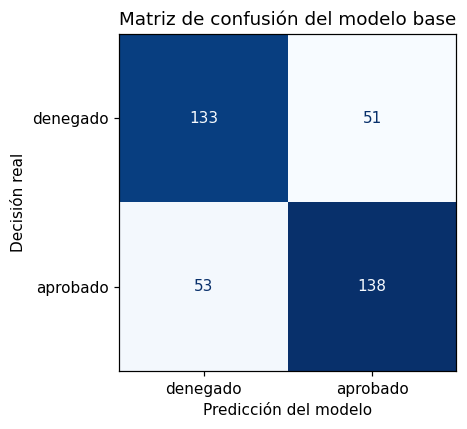

In [25]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}\n")
print(classification_report(y_test, y_pred, target_names=["denegado", "aprobado"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["denegado", "aprobado"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión del modelo base")
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Decisión real")
plt.tight_layout()
plt.show()

**Análisis de Desempeño.** El modelo presenta una exactitud cercana a 0.72 y un F1-score similar, logrando predecir correctamente la mayoría de los casos. Aunque el rendimiento es moderado debido a la naturaleza estocástica del criterio de aprobación original, es más que suficiente para analizar cómo la red está ponderando las variables.

## Etapa 2: Explicabilidad Global mediante SHAP

Utilizamos `shap.TreeExplainer` para desglosar las contribuciones. Aquí los valores se expresan en probabilidad. SHAP nos permite entender cómo cada característica desvía la predicción final respecto al valor promedio base.

In [26]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Según la versión de SHAP, un clasificador binario devuelve una lista o un arreglo 3D.
# Nos quedamos siempre con la clase 1 (aprobado).
if isinstance(shap_values, list):
    sv1 = shap_values[1]
    base_value = explainer.expected_value[1]
elif shap_values.ndim == 3:
    sv1 = shap_values[:, :, 1]
    base_value = explainer.expected_value[1]
else:
    sv1 = shap_values
    base_value = explainer.expected_value

print("Forma de los valores SHAP (casos x variables):", sv1.shape)
print(f"Valor base (probabilidad media de aprobación): {base_value:.3f}")

Forma de los valores SHAP (casos x variables): (375, 25)
Valor base (probabilidad media de aprobación): 0.509


**Gráfico Beeswarm (Enjambre).** Cada punto ilustra una observación individual. Si el punto se sitúa a la derecha del centro, significa que esa característica incrementó la probabilidad de aprobación. 

- **Poder predictivo:** La proporción deuda-ingreso (`debt_to_income`) y los ingresos (`monthly_income`) son determinantes clave.
- **Detección de Sesgos:** Se observa claramente que ser mujer (`sex_female = 1`) o extranjero (`foreign_worker_yes = 1`) reduce drásticamente las posibilidades de aprobación, revelando el sesgo introducido en la regla subyacente.

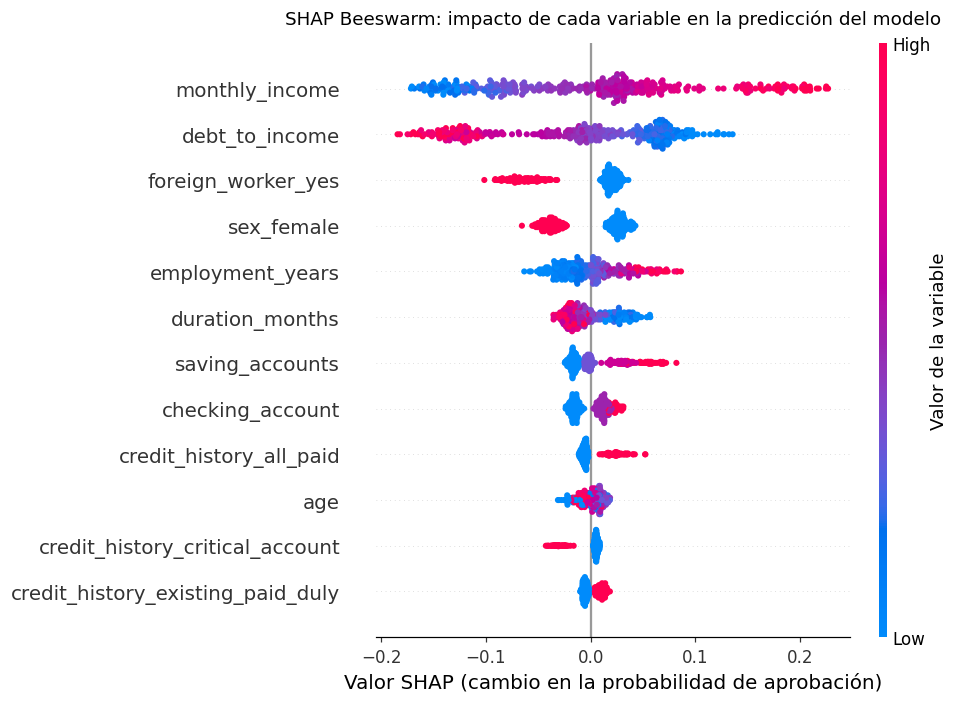

In [27]:
shap.summary_plot(sv1, X_test, max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6.5)
fig.axes[0].set_xlabel("Valor SHAP (cambio en la probabilidad de aprobación)")
fig.axes[-1].set_ylabel("Valor de la variable")
fig.axes[0].set_title("SHAP Beeswarm: impacto de cada variable en la predicción del modelo", pad=12)
plt.tight_layout()
plt.show()

Sumo la importancia de las columnas dummy para comparar por variable original. Las sensibles van en rojo.

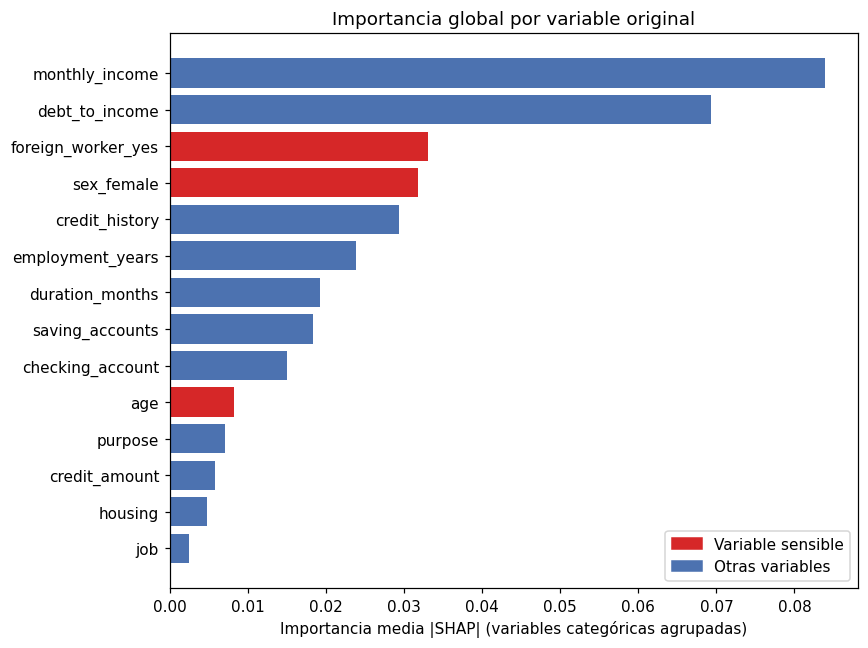

monthly_income        0.084
debt_to_income        0.069
foreign_worker_yes    0.033
sex_female            0.032
credit_history        0.029
employment_years      0.024
duration_months       0.019
saving_accounts       0.018
checking_account      0.015
age                   0.008
purpose               0.007
credit_amount         0.006
housing               0.005
job                   0.002
dtype: float64

In [28]:
def base_name(col):
    for n in nominales:
        if col.startswith(n + "_"):
            return n
    return col

agg_importance = (
    pd.Series(np.abs(sv1).mean(axis=0), index=feature_names)
    .groupby(base_name).sum()
    .sort_values(ascending=False)
)

sensibles = {"sex_female", "foreign_worker_yes", "age"}
colores = ["#d62728" if v in sensibles else "#4c72b0" for v in agg_importance.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(agg_importance.index[::-1], agg_importance.values[::-1], color=colores[::-1])
ax.set_xlabel("Importancia media |SHAP| (variables categóricas agrupadas)")
ax.set_title("Importancia global por variable original")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#d62728"), plt.Rectangle((0, 0), 1, 1, color="#4c72b0")],
          labels=["Variable sensible", "Otras variables"], loc="lower right")
plt.tight_layout()
plt.show()

agg_importance.round(3)

La tabla resume el sentido del efecto de las cuatro variables principales.

In [29]:
def resumen_variable(nombre):
    col = X_test[nombre]
    s = pd.Series(sv1[:, feature_names.index(nombre)], index=X_test.index)
    if col.nunique() == 2:
        bajo, alto, comparacion = s[col == 0].mean(), s[col == 1].mean(), "valor 0 vs valor 1"
    else:
        bajo = s[col <= col.quantile(0.25)].mean()
        alto = s[col >= col.quantile(0.75)].mean()
        comparacion = "25% más bajo vs 25% más alto"
    return {"variable": nombre, "importancia |SHAP|": s.abs().mean(),
            "SHAP medio (valores bajos)": bajo, "SHAP medio (valores altos)": alto,
            "grupos comparados": comparacion}

top = ["monthly_income", "debt_to_income", "foreign_worker_yes", "sex_female"]
pd.DataFrame([resumen_variable(v) for v in top]).set_index("variable").round(3)

,importancia |SHAP|,SHAP medio (valores bajos),SHAP medio (valores altos),grupos comparados
variable,,,,
monthly_income,0.084,-0.125,0.136,25% más bajo vs 25% más alto
debt_to_income,0.069,0.078,-0.131,25% más bajo vs 25% más alto
foreign_worker_yes,0.033,0.020,-0.064,valor 0 vs valor 1
sex_female,0.032,0.027,-0.038,valor 0 vs valor 1


### Narrativa: las 3 variables más influyentes

El beeswarm y el gráfico agregado coinciden: `monthly_income`, `debt_to_income` y `foreign_worker_yes`. La cuarta, `sex_female`, casi empata con la tercera (0.032 contra 0.033).

**1. `monthly_income` (positivo).** Es la de más peso (0.084). Los ingresos altos (rojo) empujan a aprobar y los bajos (azul) a denegar. El 25% con más ingreso recibe en promedio +0.136 y el 25% con menos ingreso recibe -0.125. Tiene sentido: más ingreso, más capacidad de pago.

**2. `debt_to_income` (negativo).** Pesa 0.069 y funciona al revés: más deuda respecto al ingreso empuja a denegar (-0.131 en el 25% más endeudado y +0.078 en el 25% menos endeudado). También es un criterio legítimo de riesgo.

**3. `foreign_worker_yes` (negativo).** Aquí aparece el problema. Los extranjeros quedan agrupados a la izquierda con -0.064 en promedio y los nacionales a la derecha con +0.020, unos 8 puntos de diferencia. Esta variable no dice nada sobre la capacidad de pago.

**`sex_female` (negativo).** Tiene el mismo patrón: las mujeres reciben -0.038 y los hombres +0.027.

Las dos pesan más que el historial crediticio (0.029), los años de empleo (0.024) y los ahorros (0.018). Esa es la señal de alerta de esta fase y la Fase 4 la revisa.

## Etapa 3: Explicabilidad Local (Casos Individuales)

A continuación, analizaremos el proceso de decisión del modelo sobre solicitudes particulares utilizando gráficos *Waterfall* de SHAP.

In [30]:
proba_test = model.predict_proba(X_test)[:, 1]
pos_approved = int(np.argmax(proba_test))
pos_denied = int(np.argmin(proba_test))

idx_approved = X_test.index[pos_approved]
idx_denied = X_test.index[pos_denied]

print(f"CASO 1 (aprobado): probabilidad de aprobación {proba_test[pos_approved]:.1%}")
display(df.loc[[idx_approved]])
print(f"\nCASO 2 (denegado): probabilidad de aprobación {proba_test[pos_denied]:.1%}")
display(df.loc[[idx_denied]])

CASO 1 (aprobado): probabilidad de aprobación 85.6%


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration_months,purpose,monthly_income,employment_years,debt_to_income,credit_history,foreign_worker,credit_risk
166,36,male,unskilled,own,rich,little,5156,13,radio/TV,3320,5.2,0.19,all_paid,no,good



CASO 2 (denegado): probabilidad de aprobación 19.8%


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration_months,purpose,monthly_income,employment_years,debt_to_income,credit_history,foreign_worker,credit_risk
297,43,female,skilled,rent,little,little,2612,41,radio/TV,1954,3.6,0.463,existing_paid_duly,yes,bad


El Caso 1 es un hombre nacional de 36 años con ingreso de 3,320, deuda del 19% de su ingreso y ahorros en el nivel más alto. El Caso 2 es una mujer extranjera de 43 años con ingreso de 1,954, deuda del 46% de su ingreso y ahorros y cuenta corriente en el nivel más bajo.

#### SHAP Waterfall: Caso 1 (aprobado)

El gráfico parte del valor base (0.509) y suma el aporte de cada variable hasta la predicción final.

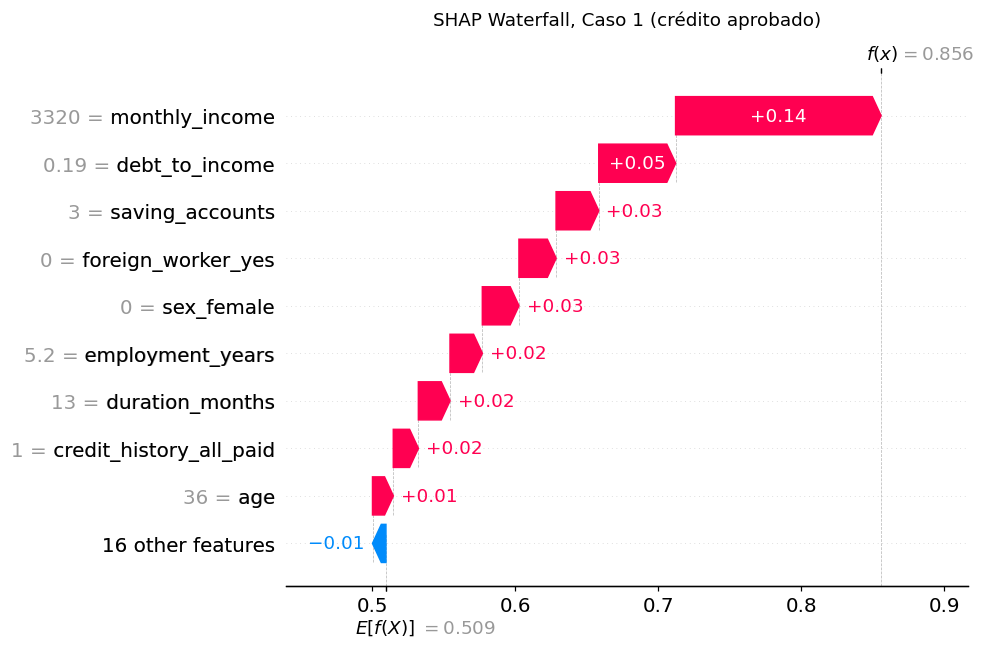

Valor base: 0.509 | Suma de aportes: +0.346 | Predicción final: 0.856
Aporte conjunto de sex_female y foreign_worker_yes en este caso: +0.052


In [31]:
exp_case1 = shap.Explanation(
    values=sv1[pos_approved],
    base_values=base_value,
    data=X_test.iloc[pos_approved].values,
    feature_names=feature_names,
)

shap.plots.waterfall(exp_case1, max_display=10, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.axes[0].set_title("SHAP Waterfall, Caso 1 (crédito aprobado)", pad=32)
plt.tight_layout()
plt.show()

aporte_sensibles = sv1[pos_approved][[feature_names.index("sex_female"), feature_names.index("foreign_worker_yes")]].sum()
print(f"Valor base: {base_value:.3f} | Suma de aportes: {sv1[pos_approved].sum():+.3f} | Predicción final: {proba_test[pos_approved]:.3f}")
print(f"Aporte conjunto de sex_female y foreign_worker_yes en este caso: {aporte_sensibles:+.3f}")

**Lectura del Caso 1.** La probabilidad sube de 0.509 a 0.856. El ingreso de 3,320 aporta +0.14, cerca de la mitad, y la deuda baja de 0.19 suma +0.05. Después vienen los ahorros altos (+0.03) y los años de empleo, el plazo corto y el historial pagado (+0.02 cada uno). Entre no ser extranjero y no ser mujer suman otros +0.052. Sin ese aporte la probabilidad sería 0.80 y la decisión sería la misma, pero una parte de la aprobación viene de variables que no deberían influir.

#### LIME: Caso 2 (denegado)

Siguiendo los pasos del curso, selecciono el Caso 2 y LIME genera 5,000 variaciones de esa solicitud. Cada variación pasa por el Random Forest y LIME ajusta un modelo lineal simple, dándole más peso a las variaciones parecidas al caso real. Los pesos de ese modelo sustituto explican la decisión para esta persona.

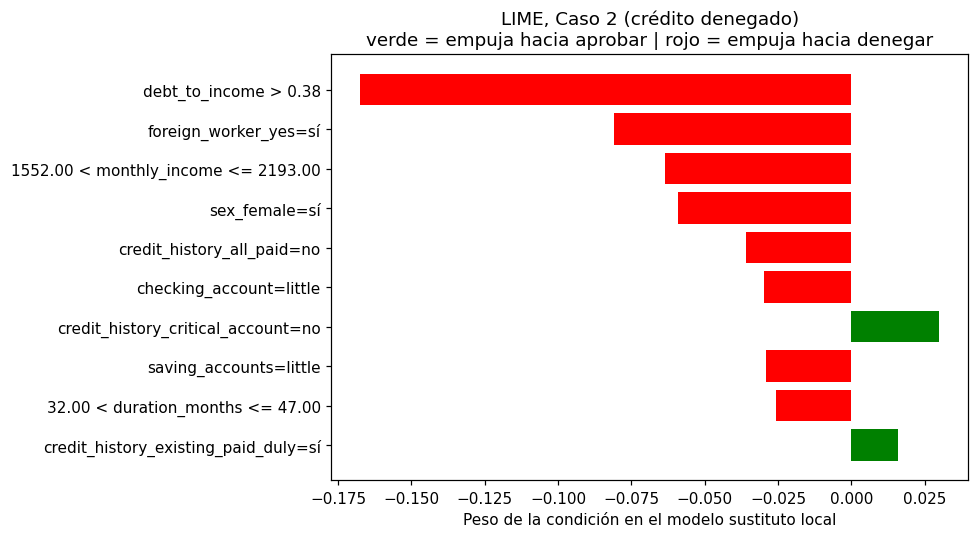

Probabilidad de aprobación del modelo: 0.198
Predicción del modelo sustituto local: 0.201
R2 del modelo sustituto local: 0.375

-0.167  debt_to_income > 0.38
-0.081  foreign_worker_yes=sí
-0.064  1552.00 < monthly_income <= 2193.00
-0.059  sex_female=sí
-0.036  credit_history_all_paid=no
-0.030  checking_account=little
+0.030  credit_history_critical_account=no
-0.029  saving_accounts=little
-0.026  32.00 < duration_months <= 47.00
+0.016  credit_history_existing_paid_duly=sí


In [32]:
binarias = ["sex_female", "foreign_worker_yes"] + [c for c in feature_names if base_name(c) in nominales]
cat_features = [feature_names.index(c) for c in binarias + list(orden)]
cat_names = {feature_names.index(c): ["no", "sí"] for c in binarias}
cat_names.update({feature_names.index(c): niveles for c, niveles in orden.items()})

def predict_fn(datos):
    return model.predict_proba(pd.DataFrame(datos, columns=feature_names))

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=["denegado", "aprobado"],
    categorical_features=cat_features,
    categorical_names=cat_names,
    mode="classification",
    random_state=42,
)

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[pos_denied].values, predict_fn, num_features=10, labels=(1,)
)

fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(9, 5)
plt.title("LIME, Caso 2 (crédito denegado)\nverde = empuja hacia aprobar | rojo = empuja hacia denegar")
plt.xlabel("Peso de la condición en el modelo sustituto local")
plt.tight_layout()
plt.show()

print(f"Probabilidad de aprobación del modelo: {proba_test[pos_denied]:.3f}")
print(f"Predicción del modelo sustituto local: {lime_exp.local_pred[0]:.3f}")
print(f"R2 del modelo sustituto local: {lime_exp.score:.3f}\n")
for regla, peso in lime_exp.as_list(label=1):
    print(f"{peso:+.3f}  {regla}")

**Lectura del Caso 2.** El Random Forest da 19.6% de probabilidad de aprobación y el modelo sustituto 20.0%, así que lo reproduce bien. Su R2 es 0.375, un ajuste moderado, por eso leo los pesos como aproximados.

El factor con más peso es la deuda (0.463, mayor a 0.38: -0.168). Le siguen ser extranjero (-0.081), el ingreso entre 1,552 y 2,193 (-0.064) y ser mujer (-0.059). El resto son factores pequeños, como la cuenta corriente y los ahorros bajos, el plazo largo y el historial. La deuda es la causa financiera principal, pero la nacionalidad pesa más que el ingreso y el sexo más que el historial, la cuenta corriente y los ahorros. LIME y SHAP coinciden.

Para medir cuánto pesan, repito la predicción con la misma persona marcada como hombre y no extranjero.

In [33]:
caso2 = X_test.iloc[[pos_denied]].copy()
caso2_sin_sensibles = caso2.copy()
caso2_sin_sensibles["sex_female"] = 0
caso2_sin_sensibles["foreign_worker_yes"] = 0

p_real = model.predict_proba(caso2)[0, 1]
p_cf = model.predict_proba(caso2_sin_sensibles)[0, 1]
print(f"Probabilidad de aprobación del Caso 2 con su perfil real:            {p_real:.1%}")
print(f"Misma persona, marcada como hombre y no extranjero (resto igual):    {p_cf:.1%}")

Probabilidad de aprobación del Caso 2 con su perfil real:            19.8%
Misma persona, marcada como hombre y no extranjero (resto igual):    34.1%


La probabilidad pasa de 19.6% a 34.0%: 14 puntos que vienen solo del sexo y la nacionalidad. La solicitud seguiría denegada (34% es menor a 50%) porque la deuda alta y el ingreso bajo el promedio la explican, pero en una solicitud más cercana al límite esos 14 puntos decidirían el resultado.

### Reto: explicación para el cliente final

Cada carta usa solo factores legítimos. Después agrego una nota interna para el equipo de riesgo, que el cliente no recibe.

**Caso 1: carta de aprobación**

> Estimado cliente: su solicitud de crédito fue aprobada. Pesaron a su favor su ingreso mensual de 3,320, que está entre los más altos de nuestros solicitantes; sus deudas bajas, que equivalen al 19% de su ingreso; y sus ahorros, en el nivel más alto de nuestra escala. También ayudaron sus créditos anteriores pagados, sus 5 años de antigüedad laboral y el plazo corto de 13 meses. Estimamos una probabilidad de aprobación de 86%.

*Nota interna:* el modelo sumó además unos 5 puntos por no ser mujer ni extranjero. No cambia el resultado y queda como hallazgo de cumplimiento.

**Caso 2: carta de denegación**

> Estimado cliente: lamentamos informarle que por ahora no podemos aprobar su solicitud. El factor principal es su nivel de endeudamiento: sus deudas equivalen al 46% de su ingreso, una proporción que está entre el 25% más alto de nuestros solicitantes. También influyeron su ingreso mensual de 1,954, por debajo del típico de nuestros solicitantes (alrededor de 2,200), los saldos bajos en sus cuentas y un plazo de 41 meses. Puede mejorar una próxima solicitud reduciendo sus deudas, acumulando saldo o pidiendo un plazo más corto. Con gusto revisamos su caso con usted.

*Nota interna:* la carta menciona solo factores financieros y por eso no debe enviarse tal cual. El modelo restó 14 puntos por ser mujer y extranjera, y omitir un factor que pesó en la decisión engaña al cliente. Hay que reevaluar la solicitud con un modelo corregido antes de comunicarla.

## Fase 4: Evaluación de IA ética

Hago cuatro comprobaciones: tasas de aprobación por grupo, efecto de cambiar solo la variable sensible, revisión de la edad y un modelo reentrenado sin las variables sensibles.

### Tasas de aprobación por grupo

Comparo la decisión histórica con la predicción del modelo. La tabla incluye la tasa histórica del dataset completo porque el conjunto de prueba es pequeño. El impacto dispar es la tasa del grupo afectado dividida entre la del grupo de referencia; menos de 0.80 se considera señal de discriminación (regla del 80%).

In [34]:
test_raw = df.loc[X_test.index]

def tabla_equidad(columna, ref, prot, nombres):
    filas = {}
    for g, nombre in zip((ref, prot), nombres):
        m = (test_raw[columna] == g).values
        completo = (df[columna] == g).values
        filas[nombre] = {"casos en prueba": int(m.sum()),
                         "aprobación histórica (dataset completo)": y.values[completo].mean(),
                         "aprobación histórica (prueba)": y_test.values[m].mean(),
                         "aprobación predicha (prueba)": y_pred[m].mean()}
    t = pd.DataFrame(filas).T
    t["casos en prueba"] = t["casos en prueba"].astype(int)
    ratio = t.iloc[1]["aprobación predicha (prueba)"] / t.iloc[0]["aprobación predicha (prueba)"]
    return t, ratio

t_sex, ratio_sex = tabla_equidad("sex", "male", "female", ["hombres", "mujeres"])
t_for, ratio_for = tabla_equidad("foreign_worker", "no", "yes", ["nacionales", "extranjeros"])

print("Por sexo"); display(t_sex.round(3))
print("Por condición de trabajador extranjero"); display(t_for.round(3))
print("Impacto dispar (aprobación predicha del grupo afectado / grupo de referencia)")
print(f"  Mujeres frente a hombres:            {ratio_sex:.2f}")
print(f"  Extranjeros frente a nacionales:     {ratio_for:.2f}   (referencia mínima aceptada: 0.80)")

Por sexo


,casos en prueba,aprobación histórica (dataset completo),aprobación histórica (prueba),aprobación predicha (prueba)
hombres,214,0.585,0.631,0.593
mujeres,161,0.404,0.348,0.385


Por condición de trabajador extranjero


,casos en prueba,aprobación histórica (dataset completo),aprobación histórica (prueba),aprobación predicha (prueba)
nacionales,267,0.552,0.551,0.558
extranjeros,108,0.387,0.407,0.370


Impacto dispar (aprobación predicha del grupo afectado / grupo de referencia)
  Mujeres frente a hombres:            0.65
  Extranjeros frente a nacionales:     0.66   (referencia mínima aceptada: 0.80)


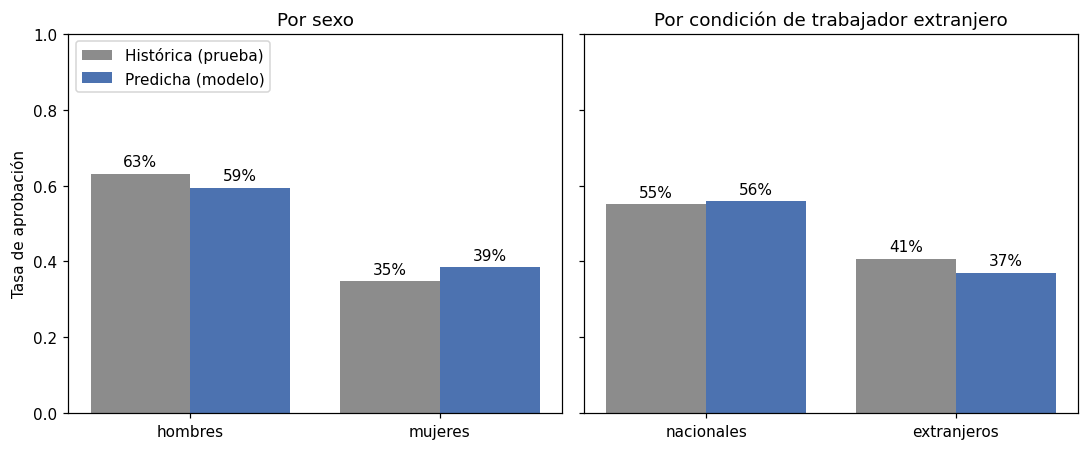

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, t, titulo in [(axes[0], t_sex, "Por sexo"), (axes[1], t_for, "Por condición de trabajador extranjero")]:
    pos = np.arange(len(t))
    ax.bar(pos - 0.2, t["aprobación histórica (prueba)"], 0.4, label="Histórica (prueba)", color="#8c8c8c")
    ax.bar(pos + 0.2, t["aprobación predicha (prueba)"], 0.4, label="Predicha (modelo)", color="#4c72b0")
    for i, (h, p) in enumerate(zip(t["aprobación histórica (prueba)"], t["aprobación predicha (prueba)"])):
        ax.text(i - 0.2, h + 0.02, f"{h:.0%}", ha="center")
        ax.text(i + 0.2, p + 0.02, f"{p:.0%}", ha="center")
    ax.set_xticks(pos)
    ax.set_xticklabels(t.index)
    ax.set_ylim(0, 1)
    ax.set_title(titulo)
axes[0].set_ylabel("Tasa de aprobación")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

### Efecto aislado de sexo y nacionalidad

Cambio solo la variable sensible en cada persona (mujer a hombre, extranjero a nacional), dejo lo demás igual y mido cuánto cambia la probabilidad de aprobación.

In [36]:
def cambio_medio(columna):
    X_cf = X_test.copy()
    X_cf[columna] = 0
    diferencia = model.predict_proba(X_cf)[:, 1] - proba_test
    return diferencia[(X_test[columna] == 1).values].mean()

print("Cambio medio en la probabilidad de aprobación al cambiar SOLO la variable sensible")
print(f"  Mujeres tratadas como hombres:          {cambio_medio('sex_female'):+.3f}")
print(f"  Extranjeros tratados como no extranjeros: {cambio_medio('foreign_worker_yes'):+.3f}")

en_grupo = ((X_test["sex_female"] == 1) | (X_test["foreign_worker_yes"] == 1)).values
X_cf = X_test.copy()
X_cf[["sex_female", "foreign_worker_yes"]] = 0
pred_cf = model.predict(X_cf)
cambian = int(((y_pred == 0) & (pred_cf == 1) & en_grupo).sum())
print(f"\nPersonas que son mujeres y/o extranjeras: {int(en_grupo.sum())} de {len(X_test)}")
print(f"De ellas, pasan de denegado a aprobado al neutralizar ambas variables: {cambian}")

print("\nSHAP medio de las variables sensibles según el grupo real")
shap_sex = pd.Series(sv1[:, feature_names.index("sex_female")], index=X_test.index)
shap_for = pd.Series(sv1[:, feature_names.index("foreign_worker_yes")], index=X_test.index)
print(f"  sex_female, mujeres:   {shap_sex[test_raw['sex'] == 'female'].mean():+.3f}")
print(f"  sex_female, hombres:   {shap_sex[test_raw['sex'] == 'male'].mean():+.3f}")
print(f"  foreign_worker_yes, extranjeros:    {shap_for[test_raw['foreign_worker'] == 'yes'].mean():+.3f}")
print(f"  foreign_worker_yes, no extranjeros: {shap_for[test_raw['foreign_worker'] == 'no'].mean():+.3f}")

Cambio medio en la probabilidad de aprobación al cambiar SOLO la variable sensible
  Mujeres tratadas como hombres:          +0.062
  Extranjeros tratados como no extranjeros: +0.086

Personas que son mujeres y/o extranjeras: 220 de 375
De ellas, pasan de denegado a aprobado al neutralizar ambas variables: 46

SHAP medio de las variables sensibles según el grupo real
  sex_female, mujeres:   -0.038
  sex_female, hombres:   +0.027
  foreign_worker_yes, extranjeros:    -0.064
  foreign_worker_yes, no extranjeros: +0.020


### Edad

La edad también es un atributo protegido en varios marcos de crédito, así que la reviso por tramos.

In [37]:
bandas = pd.cut(X_test["age"], bins=[17, 24, 64, 75], labels=["18 a 24", "25 a 64", "65 a 75"])
shap_edad = pd.Series(sv1[:, feature_names.index("age")], index=X_test.index)
display(shap_edad.groupby(bandas, observed=True).agg(["count", "mean"]).rename(
    columns={"count": "casos", "mean": "SHAP medio de age"}).round(4))

,casos,SHAP medio de age
age,,
18 a 24,52,-0.0134
25 a 64,252,0.0056
65 a 75,71,-0.0065


### Modelo sin variables sensibles

Reentreno el mismo modelo sin `sex_female` ni `foreign_worker_yes` y comparo rendimiento y brechas. También reviso si otras columnas se relacionan con ellas.

In [38]:
sensibles_cols = ["sex_female", "foreign_worker_yes"]
cols_sin = [c for c in feature_names if c not in sensibles_cols]

model_sin = RandomForestClassifier(n_estimators=400, max_depth=7, min_samples_leaf=5, random_state=42)
model_sin.fit(X_train[cols_sin], y_train)
pred_sin = model_sin.predict(X_test[cols_sin])

def brecha(pred, columna, ref):
    grupo_ref = (test_raw[columna] == ref).values
    return pred[grupo_ref].mean() - pred[~grupo_ref].mean()

comparacion = pd.DataFrame({
    "Accuracy": [acc, accuracy_score(y_test, pred_sin)],
    "F1": [f1, f1_score(y_test, pred_sin)],
    "Brecha por sexo (hombres - mujeres)": [brecha(y_pred, "sex", "male"), brecha(pred_sin, "sex", "male")],
    "Brecha por nacionalidad (no extranjeros - extranjeros)": [brecha(y_pred, "foreign_worker", "no"), brecha(pred_sin, "foreign_worker", "no")],
}, index=["Modelo con variables sensibles", "Modelo sin variables sensibles"])
display(comparacion.round(3))

otras = [c for c in feature_names if c not in sensibles_cols]
corr = X[sensibles_cols + otras].corr().loc[otras, sensibles_cols].abs().max()
print("Máxima correlación absoluta entre cada variable sensible y el resto de variables:")
print(corr.round(3).to_string())

print("\nPerfil promedio por sexo en el conjunto de prueba")
display(test_raw.groupby("sex")[["monthly_income", "debt_to_income", "employment_years"]].mean().round(2))

,Accuracy,F1,Brecha por sexo (hombres - mujeres),Brecha por nacionalidad (no extranjeros - extranjeros)
Modelo con variables sensibles,0.723,0.726,0.208,0.188
Modelo sin variables sensibles,0.715,0.724,0.078,-0.007


Máxima correlación absoluta entre cada variable sensible y el resto de variables:
sex_female            0.060
foreign_worker_yes    0.071

Perfil promedio por sexo en el conjunto de prueba


,monthly_income,debt_to_income,employment_years
sex,,,
female,2186.77,0.31,3.92
male,2184.33,0.28,4.09


### Reflexión crítica

**1. ¿Existen variables sesgadas o inapropiadas? Sí: sexo y nacionalidad.**

En el dataset completo se aprobó al 58.5% de los hombres y al 40.4% de las mujeres, y al 55.2% de los nacionales frente al 38.7% de los extranjeros. El modelo aprendió ese patrón: predice aprobación para 59.3% de los hombres y 38.5% de las mujeres, y para 55.8% de los nacionales y 37.0% de los extranjeros. El impacto dispar es 0.65 para mujeres y 0.66 para extranjeros, ambos bajo 0.80.

La prueba contrafactual confirma que el efecto viene de la variable y no de diferencias de perfil. Tratar a las mujeres como hombres sube su probabilidad 6.2 puntos en promedio, y tratar a los extranjeros como nacionales la sube 8.6 puntos. De las 220 personas de prueba que son mujeres o extranjeras, 46 pasan de denegado a aprobado solo con neutralizar esas dos variables.

**2. ¿El modelo decide con características irrelevantes o discriminatorias? Sí.**

Nacionalidad y sexo son la tercera y cuarta variable en importancia, por encima del historial crediticio, los años de empleo y los ahorros. Ninguna tiene relación con la capacidad de pago, y su peso viene de decisiones pasadas que están en los datos. El Caso 2 muestra el efecto acumulado: una mujer extranjera pierde 14 puntos por esas dos condiciones.

Es lo mismo que el ejemplo del lobo con fondo de nieve del curso: la explicación revela que el modelo se apoya en algo ajeno a la tarea. Aquí ese fondo de nieve es el sexo y la nacionalidad.

La edad tiene un efecto menor (importancia de 0.008): el modelo resta 1.3 puntos en promedio a los de 18 a 24 años y 0.7 a los de 65 a 75. Vale revisarla, pero no se compara con los otros dos.

**3. Problemas en los datos.**

- **La etiqueta es una decisión pasada.** `credit_risk` registra si se aprobó el crédito, no si la persona pagó. Un modelo que imita esas decisiones hereda sus sesgos.
- **Grupos pequeños.** Las mujeres son el 41% de los casos y los extranjeros el 25%, y con grupos pequeños las estimaciones son más ruidosas.
- **Datos sintéticos.** Aquí las variables sensibles casi no se relacionan con las demás (correlación máxima de 0.071). En datos reales suelen existir variables que las reemplazan, como el código postal, y reintroducen el sesgo.

**4. Qué pasa al quitar las variables sensibles.** La brecha por nacionalidad baja de 18.8 a -0.7 puntos y la de sexo de 20.8 a 7.8, con accuracy de 0.715 y F1 de 0.724 (antes 0.723 y 0.726), así que casi no se pierde rendimiento. La brecha que queda por sexo viene de las demás variables: en la prueba las mujeres tienen algo más de deuda (0.31 contra 0.28) y menos años de empleo (3.92 contra 4.09).

**5. Recomendaciones.**

1. Sacar `sex` y `foreign_worker` del modelo y revisar que ninguna otra columna las reemplace.
2. Medir equidad junto con accuracy y F1 antes de desplegar.
3. Entrenar con el comportamiento de pago real y no con decisiones pasadas.
4. Auditar con SHAP y LIME cada cierto tiempo y pasar por cumplimiento las decisiones de alto impacto.

SHAP y LIME describen cómo decide el modelo, pero no prueban por qué existe el sesgo.

## Conclusión

El Random Forest alcanza 0.72 de accuracy y 0.73 de F1, y con esas métricas parecería aceptable. SHAP y LIME muestran que el ingreso y la deuda mandan, como debe ser, pero la nacionalidad y el sexo pesan más que el historial crediticio y restan entre 6 y 9 puntos de probabilidad a los grupos afectados. Las métricas de rendimiento no detectan eso; la explicabilidad y las métricas de equidad sí. Antes de llevar un modelo así a producción hay que quitar las variables sensibles, revisar posibles reemplazos y verificar que la etiqueta no arrastre decisiones injustas del pasado.

## Referencias

Tome como referecia:
Kodigo. (s. f.). *Interpretabilidad de modelos: SHAP, LIME*. Bootcamp Python para Ciencia de Datos, Módulo 2: Machine Learning Avanzado y Feature Engineering, Semana 8.